## Data Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
df = pd.read_csv("cogs_164_final_project/data/cogs_164_survey_responses.csv")
df.head()

,Timestamp,Email Address,Score,Sex,Which category describes you? Select all that apply.,Are you a student?,"1. When I am working on something, I cannot relax until it is perfect",2. One of my goals is to be perfect in everything I do,3. I never aim for perfection in my work,4. I seldom feel the need to be perfect,...,49. It is hard for me to relax when I’m not working,"50. I spend more time working than on socializing with friends, on hobbies or on leisure activities",51. I dive into projects to get a head start before all the phases have been finalized,52. I get upset with myself for making even the smallest mistake,"53. I put more thought, time, and energy into my work than I do into my relationships, with my spouse, (or lover) and family","54. I forget, ignore or minimize important family celebrations such as birthdays, reunions, anniversaries or holidays",55. I make important decisions before I have all the facts and have a chance to think them through thoroughly,total sum score for WART,Risk category WART,Column 1
0,2/28/2025 1:18:56,NaN,NaN,Female,Multiethnic,Not a UCSD student,4.0,3.0,7.0,7.0,...,2.0,2.0,3.0,2.0,1.0,2.0,2.0,59.0,medium,NaN
1,2/18/2025 16:26:02,NaN,NaN,Male,White,UCSD student,5.0,3.0,6.0,5.0,...,3.0,3.0,3.0,2.0,1.0,2.0,1.0,61.0,medium,NaN
2,2/25/2025 17:10:56,NaN,NaN,Male,Asian,Not a UCSD student,5.0,6.0,6.0,6.0,...,3.0,3.0,2.0,4.0,2.0,2.0,1.0,69.0,high,NaN
3,2/26/2025 9:00:25,NaN,NaN,Female,"Asian, Middle Eastern or North African",Not a UCSD student,5.0,3.0,2.0,6.0,...,2.0,1.0,2.0,2.0,1.0,2.0,4.0,62.0,medium,NaN
4,2/26/2025 15:58:39,NaN,NaN,Male,Asian,Not a UCSD student,6.0,5.0,6.0,6.0,...,2.0,3.0,3.0,2.0,2.0,2.0,1.0,63.0,medium,NaN


## Data Wrangling

In [3]:
# only want rows and columns with actual responses
survey = df.loc[:31]
survey.drop(columns=['Email Address', 'Score', 'Column 1'], inplace=True)
survey.head()

,Timestamp,Sex,Which category describes you? Select all that apply.,Are you a student?,"1. When I am working on something, I cannot relax until it is perfect",2. One of my goals is to be perfect in everything I do,3. I never aim for perfection in my work,4. I seldom feel the need to be perfect,5. I strive to be as perfect as I can be,6. It is very important that I am perfect in everything I attempt,...,48. I tend to put myself under pressure with self-imposed deadlines when I work,49. It is hard for me to relax when I’m not working,"50. I spend more time working than on socializing with friends, on hobbies or on leisure activities",51. I dive into projects to get a head start before all the phases have been finalized,52. I get upset with myself for making even the smallest mistake,"53. I put more thought, time, and energy into my work than I do into my relationships, with my spouse, (or lover) and family","54. I forget, ignore or minimize important family celebrations such as birthdays, reunions, anniversaries or holidays",55. I make important decisions before I have all the facts and have a chance to think them through thoroughly,total sum score for WART,Risk category WART
0,2/28/2025 1:18:56,Female,Multiethnic,Not a UCSD student,4.0,3.0,7.0,7.0,5.0,2.0,...,2.0,2.0,2.0,3.0,2.0,1.0,2.0,2.0,59.0,medium
1,2/18/2025 16:26:02,Male,White,UCSD student,5.0,3.0,6.0,5.0,6.0,2.0,...,3.0,3.0,3.0,3.0,2.0,1.0,2.0,1.0,61.0,medium
2,2/25/2025 17:10:56,Male,Asian,Not a UCSD student,5.0,6.0,6.0,6.0,7.0,4.0,...,3.0,3.0,3.0,2.0,4.0,2.0,2.0,1.0,69.0,high
3,2/26/2025 9:00:25,Female,"Asian, Middle Eastern or North African",Not a UCSD student,5.0,3.0,2.0,6.0,1.0,1.0,...,4.0,2.0,1.0,2.0,2.0,1.0,2.0,4.0,62.0,medium
4,2/26/2025 15:58:39,Male,Asian,Not a UCSD student,6.0,5.0,6.0,6.0,6.0,5.0,...,4.0,2.0,3.0,3.0,2.0,2.0,2.0,1.0,63.0,medium


In [4]:
# renaming columns of interest for easier analysis
survey.rename(columns={"total score: SOP": "SOP_score", "total score; SPP": "SPP_score", "Category": "SPP_category", "total sum score for WART": "WART_score", "Risk category WART": "WART_category"}, inplace=True)
survey.head()

,Timestamp,Sex,Which category describes you? Select all that apply.,Are you a student?,"1. When I am working on something, I cannot relax until it is perfect",2. One of my goals is to be perfect in everything I do,3. I never aim for perfection in my work,4. I seldom feel the need to be perfect,5. I strive to be as perfect as I can be,6. It is very important that I am perfect in everything I attempt,...,48. I tend to put myself under pressure with self-imposed deadlines when I work,49. It is hard for me to relax when I’m not working,"50. I spend more time working than on socializing with friends, on hobbies or on leisure activities",51. I dive into projects to get a head start before all the phases have been finalized,52. I get upset with myself for making even the smallest mistake,"53. I put more thought, time, and energy into my work than I do into my relationships, with my spouse, (or lover) and family","54. I forget, ignore or minimize important family celebrations such as birthdays, reunions, anniversaries or holidays",55. I make important decisions before I have all the facts and have a chance to think them through thoroughly,WART_score,WART_category
0,2/28/2025 1:18:56,Female,Multiethnic,Not a UCSD student,4.0,3.0,7.0,7.0,5.0,2.0,...,2.0,2.0,2.0,3.0,2.0,1.0,2.0,2.0,59.0,medium
1,2/18/2025 16:26:02,Male,White,UCSD student,5.0,3.0,6.0,5.0,6.0,2.0,...,3.0,3.0,3.0,3.0,2.0,1.0,2.0,1.0,61.0,medium
2,2/25/2025 17:10:56,Male,Asian,Not a UCSD student,5.0,6.0,6.0,6.0,7.0,4.0,...,3.0,3.0,3.0,2.0,4.0,2.0,2.0,1.0,69.0,high
3,2/26/2025 9:00:25,Female,"Asian, Middle Eastern or North African",Not a UCSD student,5.0,3.0,2.0,6.0,1.0,1.0,...,4.0,2.0,1.0,2.0,2.0,1.0,2.0,4.0,62.0,medium
4,2/26/2025 15:58:39,Male,Asian,Not a UCSD student,6.0,5.0,6.0,6.0,6.0,5.0,...,4.0,2.0,3.0,3.0,2.0,2.0,2.0,1.0,63.0,medium


In [5]:
# isolating columns of interest
results = survey[['SOP_score', 'SOP_category', 'SPP_score', 'SPP_category', 'WART_score', 'WART_category']]
results.head()

,SOP_score,SOP_category,SPP_score,SPP_category,WART_score,WART_category
0,50,low,41,low,59.0,medium
1,62,medium,54,low,61.0,medium
2,83,medium,63,medium,69.0,high
3,62,medium,30,low,62.0,medium
4,85,medium,64,medium,63.0,medium


In [6]:
results.shape

(32, 6)

Plotting SPP against WART, I can see that there is a general trend of those who scored medium for SPP are all on the higher side of workaholism / WART. 

<Axes: xlabel='SPP_score', ylabel='Count'>

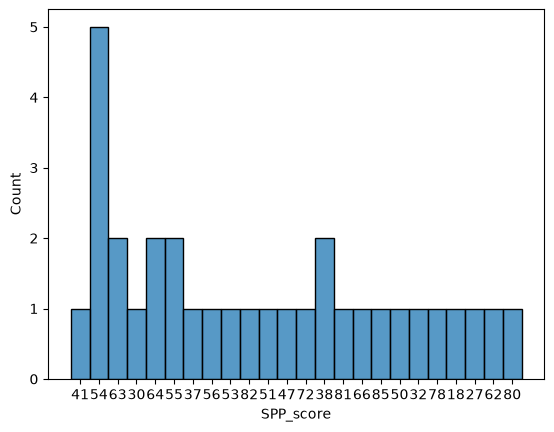

In [7]:
sns.histplot(data=results, x='SPP_score')

<Axes: xlabel='WART_score', ylabel='Count'>

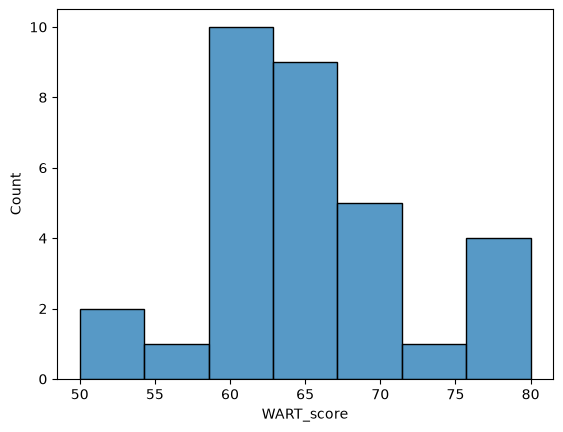

In [8]:
sns.histplot(data=results, x='WART_score')

In [9]:
results.dtypes

SOP_score            str
SOP_category         str
SPP_score            str
SPP_category         str
WART_score       float64
WART_category        str
dtype: object

In [10]:
results["SOP_score"] = pd.to_numeric(results["SOP_score"])
results["SPP_score"] = pd.to_numeric(results["SPP_score"])

In [11]:
results.dtypes

SOP_score          int64
SOP_category         str
SPP_score          int64
SPP_category         str
WART_score       float64
WART_category        str
dtype: object

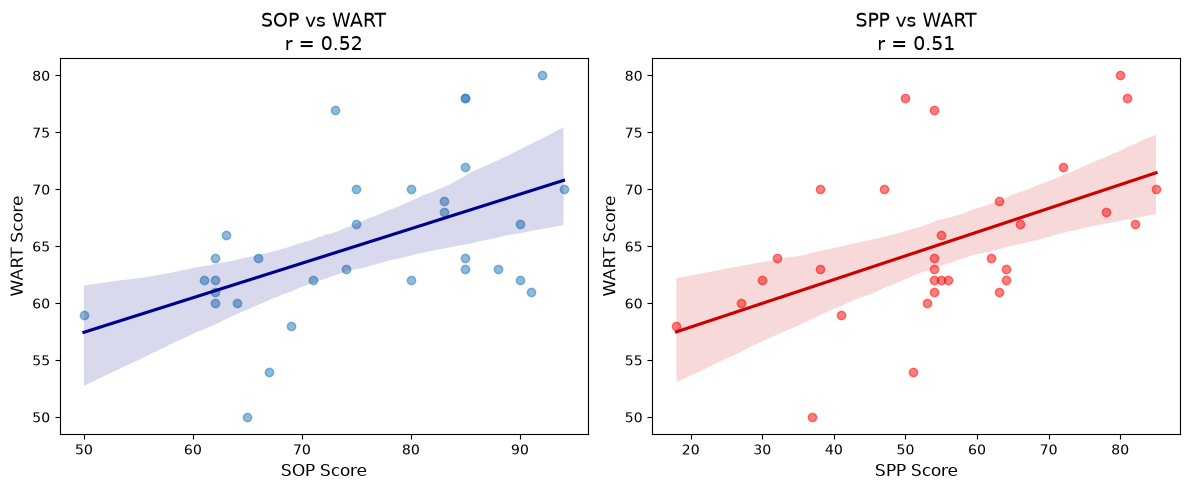

In [12]:
corr_sop = results["SOP_score"].corr(results["WART_score"])
corr_spp = results["SPP_score"].corr(results["WART_score"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Create a 1-row, 2-column subplot

# First scatterplot
sns.regplot(data=results, x="SOP_score", y="WART_score", scatter_kws={'alpha':0.5}, line_kws={"color": "#00008b"}, ax=axes[0])
axes[0].set_title(f"SOP vs WART\nr = {corr_sop:.2f}", fontsize=14)  # Display correlation in title
axes[0].set_xlabel("SOP Score", fontsize=12)
axes[0].set_ylabel("WART Score", fontsize=12)

# Second scatterplot
sns.regplot(data=results, x="SPP_score", y="WART_score", scatter_kws={'alpha':0.5,'color': 'red'}, line_kws={"color": "#cc0000"}, ax=axes[1])
axes[1].set_title(f"SPP vs WART\nr = {corr_spp:.2f}", fontsize=14)  # Display correlation in title
axes[1].set_xlabel("SPP Score", fontsize=12)
axes[1].set_ylabel("WART Score", fontsize=12)

plt.tight_layout()  # Adjust spacing
plt.show()

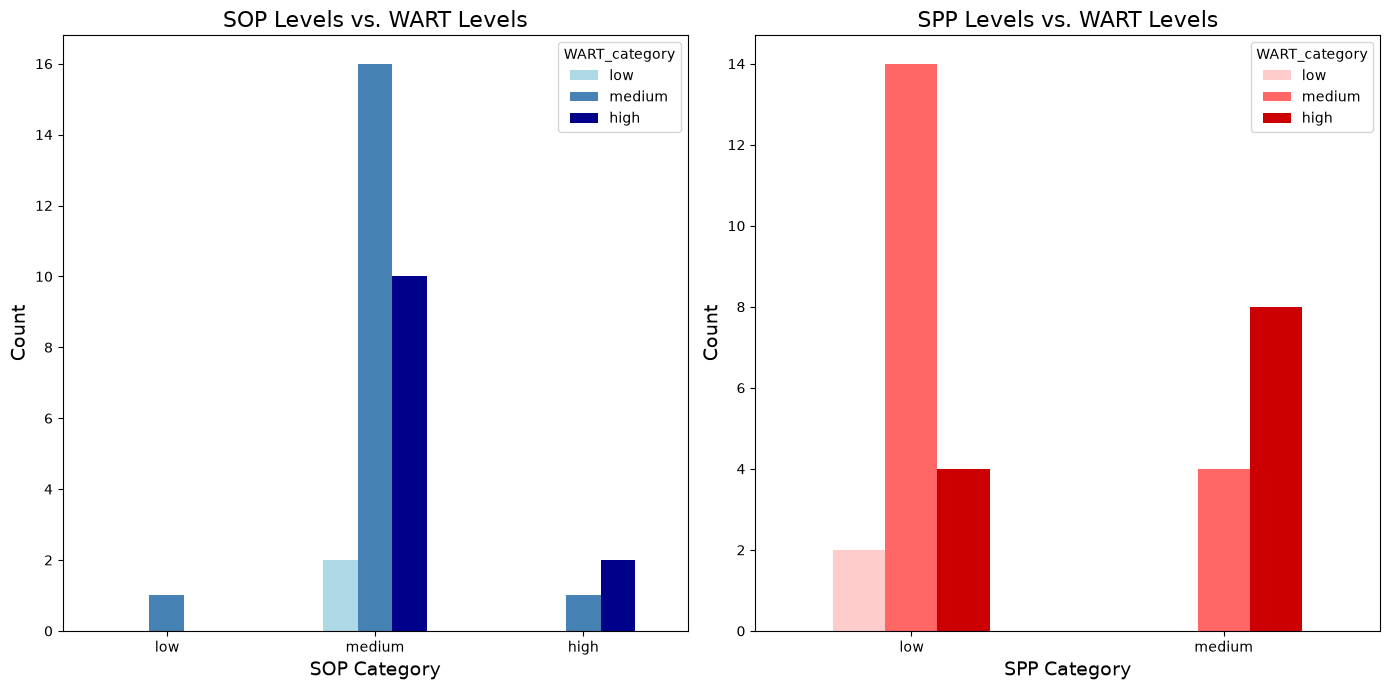

In [13]:
# Define the correct order for categories
category_order = ["low", "medium", "high"]

# Custom color palettes
palette1 = ["#add8e6", "#4682b4", "#00008b"]  # Light blue, medium blue, dark blue
palette2 = ["#ffcccc", "#ff6666", "#cc0000"]  # Light red, medium red, dark red

# First plot: Count occurrences of categorical combinations for SOP vs. WART
cat_counts_sop = results.groupby(["SOP_category", "WART_category"]).size().unstack()

# Second plot: Count occurrences of categorical combinations for SPP vs. WART
cat_counts_spp = results.groupby(["SPP_category", "WART_category"]).size().unstack()

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 7))  # Adjust figsize as needed

# Plot the first grouped bar chart (SOP vs WART) with palette1
cat_counts_sop = cat_counts_sop[category_order].reindex(category_order)  # Reorder both rows and columns
cat_counts_sop.plot(kind="bar", stacked=False, color=palette1, ax=axes[0])
axes[0].set_ylabel("Count", fontsize=14)
axes[0].set_title("SOP Levels vs. WART Levels", fontsize=16)
axes[0].set_xlabel("SOP Category", fontsize=14)
axes[0].set_xticklabels(cat_counts_sop.index, rotation=0)

# Plot the second grouped bar chart (SPP vs WART) with palette2
cat_counts_spp = cat_counts_spp[category_order]  # Reorder the columns based on category order
cat_counts_spp.plot(kind="bar", stacked=False, color=palette2, ax=axes[1])
axes[1].set_ylabel("Count", fontsize=14)
axes[1].set_title("SPP Levels vs. WART Levels", fontsize=16)
axes[1].set_xlabel("SPP Category", fontsize=14)
axes[1].set_xticklabels(cat_counts_spp.index, rotation=0)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

/var/folders/l0/dm0y29_n54vfb4qncnwsx4rm0000gn/T/ipykernel_54452/2468668462.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results, x="SOP_category", y="WART_score", palette=palette1, ax=axes[0])
/var/folders/l0/dm0y29_n54vfb4qncnwsx4rm0000gn/T/ipykernel_54452/2468668462.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results, x="SPP_category", y="WART_score", palette=palette2, ax=axes[1])
/var/folders/l0/dm0y29_n54vfb4qncnwsx4rm0000gn/T/ipykernel_54452/2468668462.py:15: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.boxplot(data=results, x="SPP_category", y="WART_score", palette=palette2, ax=axes[1])


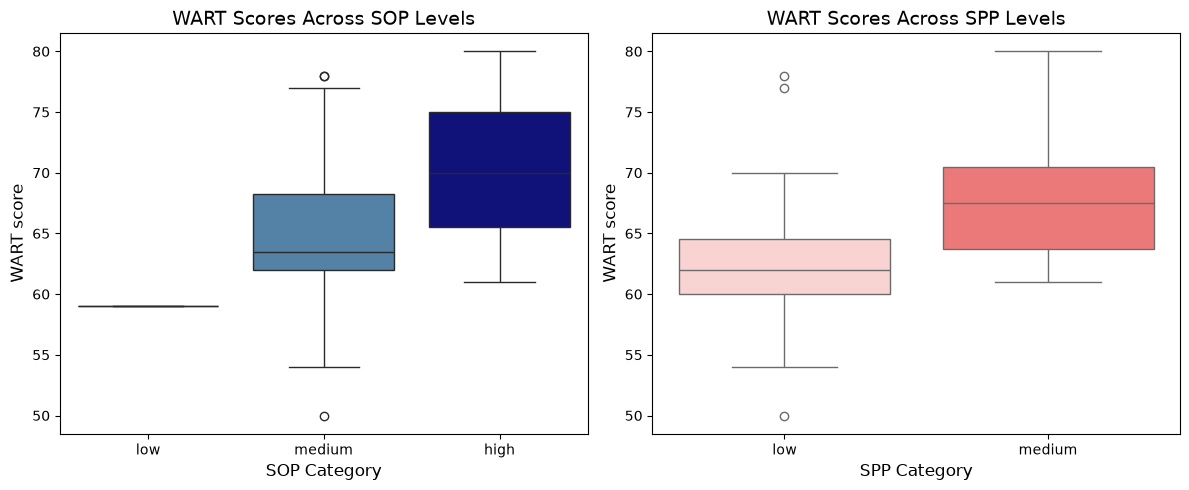

In [14]:
# custom color palettes
palette1 = ["#add8e6", "#4682b4", "#00008b"]  # Light blue, medium blue, dark blue
palette2 = ["#ffcccc", "#ff6666", "#cc0000"]  # Light red, medium red, dark red

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Adjust figsize as needed

# First boxplot (SOP vs WART)
sns.boxplot(data=results, x="SOP_category", y="WART_score", palette=palette1, ax=axes[0])
axes[0].set_xlabel("SOP Category", fontsize=12)
axes[0].set_ylabel("WART score", fontsize=12)
axes[0].set_title("WART Scores Across SOP Levels", fontsize=14)

# Second boxplot (SPP vs WART)
sns.boxplot(data=results, x="SPP_category", y="WART_score", palette=palette2, ax=axes[1])
axes[1].set_xlabel("SPP Category", fontsize=12)
axes[1].set_ylabel("WART score", fontsize=12)
axes[1].set_title("WART Scores Across SPP Levels", fontsize=14)

plt.tight_layout()  # Adjust spacing
plt.show()

Title in slide: Both SOP & SPP 